<a href="https://colab.research.google.com/github/mahesh123babu/Capstone-project-covid-19-/blob/main/COVID_19_Trend_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!pip install prophet
!pip install plotly

In [40]:
import pandas as pd
import plotly.express as px
from prophet import Prophet
import matplotlib.pyplot as plt

In [41]:
url_confirmed = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
url_deaths = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv"
url_recovered = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_recovered_global.csv"

confirmed = pd.read_csv(url_confirmed)
deaths = pd.read_csv(url_deaths)
recovered = pd.read_csv(url_recovered)

In [42]:
confirmed = confirmed.drop(['Province/State','Lat','Long'], axis=1)
confirmed = confirmed.groupby('Country/Region').sum()
confirmed = confirmed.T

confirmed.index = pd.to_datetime(confirmed.index)
confirmed.head()

Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,2,0,0,0,0,0


In [43]:
global_cases = confirmed.sum(axis=1)

df_global = pd.DataFrame({
    "Date": global_cases.index,
    "Confirmed": global_cases.values
})

fig = px.line(df_global, x="Date", y="Confirmed",
              title="Global COVID-19 Confirmed Cases Trend")

fig.show()

In [44]:
india_cases = confirmed['India']

df_india = pd.DataFrame({
    "Date": india_cases.index,
    "Cases": india_cases.values
})

fig = px.line(df_india, x="Date", y="Cases",
              title="COVID-19 Cases in India")

fig.show()

In [45]:
prophet_df = df_india.rename(columns={
    "Date": "ds",
    "Cases": "y"
})

prophet_df.head()

,ds,y
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,0
3,2020-01-25,0
4,2020-01-26,0


In [46]:
model = Prophet()
model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [47]:
future = model.make_future_dataframe(periods=7)

forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1145,2023-03-12,4.429600e+07,4.392337e+07,4.466742e+07
1146,2023-03-13,4.427950e+07,4.392587e+07,4.464079e+07
1147,2023-03-14,4.426800e+07,4.390402e+07,4.461745e+07
1148,2023-03-15,4.426391e+07,4.387381e+07,4.465701e+07
1149,2023-03-16,4.425821e+07,4.388901e+07,4.466224e+07


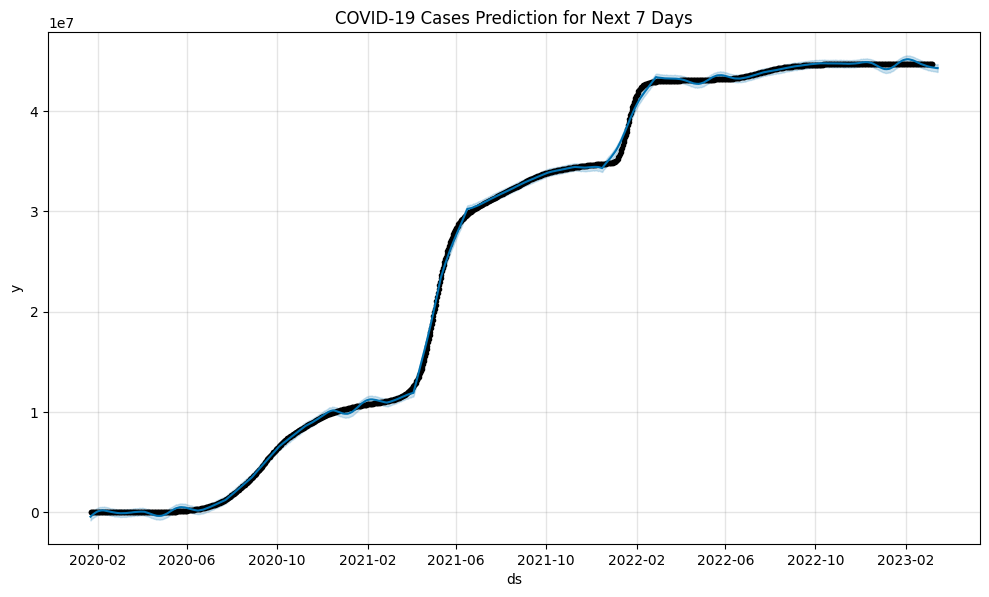

In [48]:
fig1 = model.plot(forecast)
plt.title("COVID-19 Cases Prediction for Next 7 Days")
plt.show()

In [49]:
forecast_plot = forecast[['ds','yhat']]

fig = px.line(forecast_plot,
              x="ds",
              y="yhat",
              title="Predicted COVID-19 Cases Trend")

fig.show()